<a href="https://colab.research.google.com/github/alitourani/vision-paper-hub/blob/main/categories/depth-estimator/depth-pro/depth-pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👁️‍🗨️ Vision Paper Hub** / **Depth Estimation** / **Depth Pro (Apple AI)**

This colaboratory is made to assess the quality of the **Depth Pro** library for absolute depth estimation.

- 🚀 [Benchmark](https://github.com/alitourani/vision-paper-hub/tree/main/categories/depth-estimator/depth-pro)
- 🔗 [GitHub Repo](https://github.com/apple/ml-depth-pro)
- 📃 [Paper](https://doi.org/10.48550/arXiv.2410.02073)

## **I. Install the Depth Pro Library**

- First, you need to clone and install the framework:

- ⚠️ You might see a "Restart Session" warning during the first run in Google Colab due to library version mismatches. This is expected! Accept the restart, re-run this cell, and continue!

In [1]:
# Clone the repo
!git clone https://github.com/apple/ml-depth-pro.git

# Install the dependencies
%cd ml-depth-pro
!pip install -e .

# Add the repository to the Python path
import sys
sys.path.append('/content/ml-depth-pro')

# Go back to the root
%cd ..

Cloning into 'ml-depth-pro'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 50 (delta 10), reused 2 (delta 2), pack-reused 21 (from 1)
Receiving objects: 100% (50/50), 2.50 MiB | 48.36 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/ml-depth-pro
Obtaining file:///content/ml-depth-pro
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 103.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 108.8 MB/s eta 0:00:00
  Building editable for depth_pro (pyproject.toml) ... 

/content


- Then, you will need to download pretrained checkpoints using the code snippet below:

In [5]:
# Install the dependencies
%cd ml-depth-pro

# Download models in the 'checkpoints' directory.
!source get_pretrained_models.sh

# Go back to the root
%cd ..

/content/ml-depth-pro
--2026-09-17 14:55:54--  https://ml-site.cdn-apple.com/models/depth-pro/depth_pro.pt
Resolving ml-site.cdn-apple.com (ml-site.cdn-apple.com)... 17.253.118.202, 17.253.118.201, 2403:300:a32:f100::2, ...
Connecting to ml-site.cdn-apple.com (ml-site.cdn-apple.com)|17.253.118.202|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1904446787 (1.8G) [binary/octet-stream]
Saving to: ‘checkpoints/depth_pro.pt.1’

depth_pro.pt.1      100%[===================>]   1.77G  21.6MB/s    in 86s     

2026-09-17 14:57:21 (21.1 MB/s) - ‘checkpoints/depth_pro.pt.1’ saved [1904446787/1904446787]

/content


## **II. Upload an Image**

Saving iStock-1441416721.jpg to iStock-1441416721 (1).jpg
- File "iStock-1441416721 (1).jpg" uploaded with length 540206 bytes.


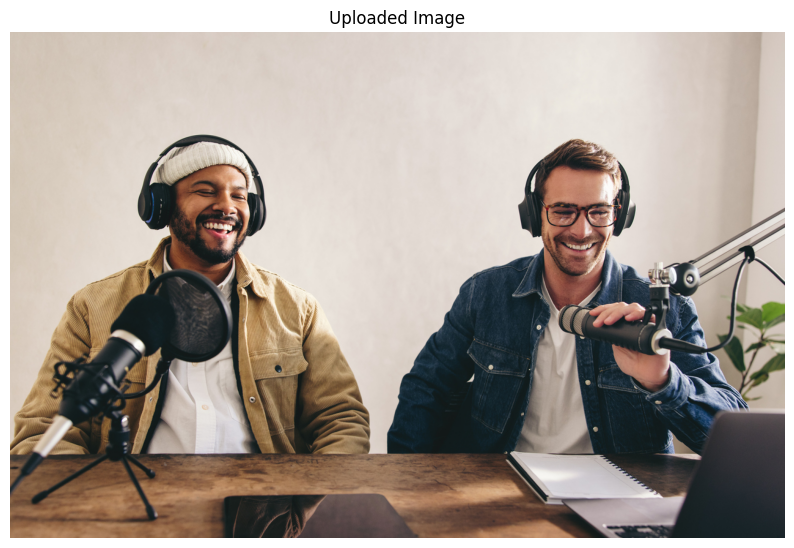

In [6]:
import os
import tempfile
import cv2 as cv
import numpy as np
import PIL.Image as Image
from google.colab import files
import matplotlib.pyplot as plt

# Variable for uploading files
image_path = ""
image_cv = None
image_pil = None
uploaded = files.upload()

for fn in uploaded.keys():
  print('- File "{name}" uploaded with length {length} bytes.'.format(
      name=fn, length=len(uploaded[fn])))

  # Save the uploaded file to a temporary location
  suffix = os.path.splitext(fn)[1] # Get extension
  with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp_file:
    tmp_file.write(uploaded[fn])
    image_path = tmp_file.name

  try:
    # Load the image using OpenCV
    image_cv = cv.imread(image_path)
    # Load as PIL image
    image_pil = Image.fromarray(cv.cvtColor(image_cv, cv.COLOR_BGR2RGB))
  except Exception as X:
    print(f"[Error]: Could not load image '{fn}' with OpenCV!")

  # Display the image
  if image_pil is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()

## **III. Use the 'Depth Pro' Model**

- First, initialize the model for the process:

In [7]:
import torch
import depth_pro

# Prepare the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and preprocessing transform
%cd ml-depth-pro
model, transform = depth_pro.create_model_and_transforms(
  device=device,
  precision=torch.half,
)
%cd ..

# Call the eval() function to prepare the model
model.eval()

/content/ml-depth-pro
/content


DepthPro(
  (encoder): DepthProEncoder(
    (patch_encoder): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp)

### III.A. Calculate the **Raw Depth**:

- Estimated focal length: 1515.3935546875


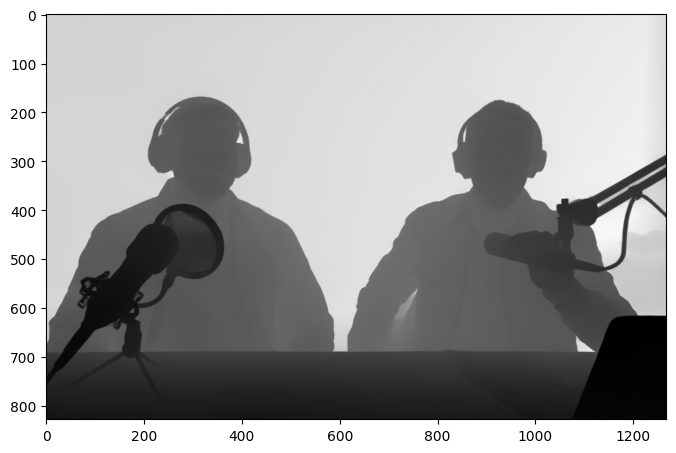

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load image and focal length
image, _, f_px = depth_pro.load_rgb(image_path)

# Run prediction. If `f_px` is provided, it is used to estimate the final metric depth,
# otherwise, the model estimates `f_px` to compute the depth metricness.
prediction = model.infer(transform(image), f_px=f_px)

# Extract the depth and focal length.
depth = prediction["depth"].detach().cpu().numpy().squeeze()

# Provide the checks with the focal lenth
if f_px is not None:
  print(f"- Estimated focal length (from exif): {f_px:0.2f}")
elif prediction["focallength_px"] is not None:
  # Get the real focal length values
  focallength_px = prediction["focallength_px"].detach().cpu().item()
  print(f"- Estimated focal length: {focallength_px}")

# Refine and normalize the depth
max_depth_vizu = min(depth.max(), 1 / 0.1)
min_depth_vizu = max(depth.min(), 1 / 250)
depth_clipped = np.clip(depth, min_depth_vizu, max_depth_vizu)
depth_normalized = (depth_clipped - min_depth_vizu) / (max_depth_vizu - min_depth_vizu)

grayscale_depth = (depth_normalized * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(grayscale_depth, cmap='gray')
plt.show()

### III.B. Calculate the **Inverse Depth**:

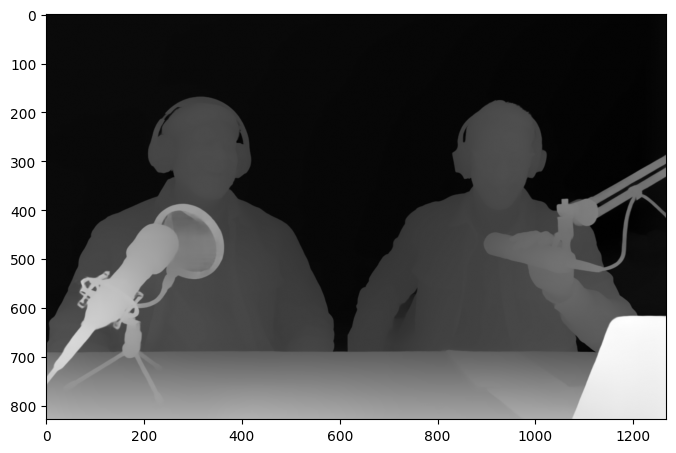

In [12]:
# Calculate inverse depth
inverse_depth = 1 / depth

max_invdepth_vizu = inverse_depth.max()
min_invdepth_vizu = inverse_depth.min()

# Normalization
inverse_depth_normalized = (inverse_depth - min_invdepth_vizu) / (max_invdepth_vizu - min_invdepth_vizu)

# Grayscale
inverse_depth_grayscale = (inverse_depth_normalized * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(inverse_depth_grayscale, cmap='gray')
plt.show()

### III.C. Calculate the **Color Inverse Depth**:

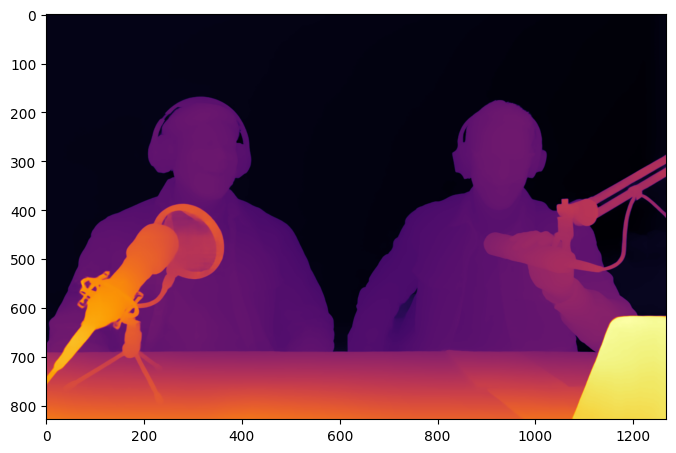

In [13]:
# Save as color-mapped "turbo" jpg image.
cmap = plt.get_cmap("inferno")

# Color depth
color_depth = (cmap(inverse_depth_normalized)[..., :3] * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(color_depth, cmap='gray')
plt.show()

### III.D. Calculate the **Surface Normal**:

- To better show the orientation of a subject in 3D space and reveal the local geometric cues that are not apparent in a depth map or segmentation mask, we can show the Surface Normals.

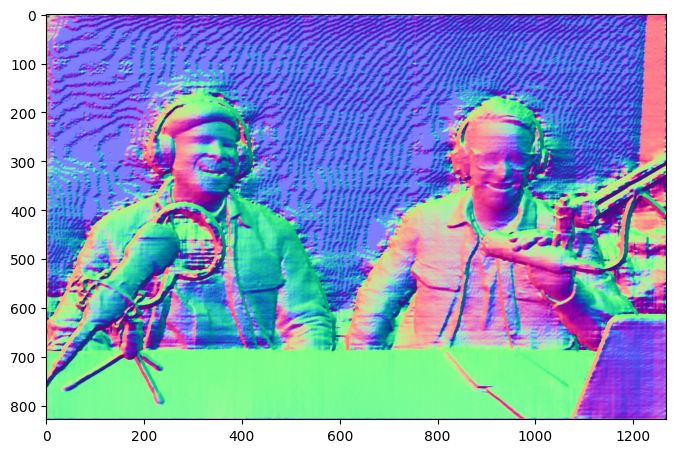

In [14]:
import cv2 as cv

# Variables
kernel_size = 7

# Apply edge detection
grad_x = cv.Sobel(depth.astype(np.float32), cv.CV_32F, 1, 0, ksize = kernel_size)
grad_y = cv.Sobel(depth.astype(np.float32), cv.CV_32F, 0, 1, ksize = kernel_size)
z = np.full(grad_x.shape, 1)

# Calculate normals
normals = np.dstack((-grad_x, -grad_y, z))
normals_mag = np.linalg.norm(normals, axis= 2, keepdims=True)

with np.errstate(divide="ignore", invalid="ignore"):
  normals_normalized = normals / (normals_mag + 1e-5)

# Calculate all the normals
normals_normalized = np.nan_to_num(normals_normalized, nan = -1, posinf=-1, neginf=-1)

# Calculate the depth-based ones
normal_from_depth = ((normals_normalized + 1) / 2 * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(normal_from_depth, cmap='gray')
plt.show()